In [1]:
import pandas as pd
import numpy as np

# LOADING THE DATA
try:
    df = pd.read_excel('final_dataset.xlsx')
    print(f"Successfully loaded final_dataset.xlsx with {len(df)} families.")
except FileNotFoundError:
    print("Error: 'final_dataset.xlsx' not found. Please run the previous data engineering block first.")
    exit()

# DEFINING EXCLUSION CRITERIA & POLICY BRACKETS
# Haryana PPP specifies > ₹1.80 Lakh annual income is an automatic exclusion.
# Matching this against the 'familyRange' standard text brackets.
high_income_brackets = [
    '180001-300000',
    '300001-500000',
    '500001-600000',
    '600001-800000',
    '800001-1000000',
    '1000000 AND ABOVE'
]

# Assuming every family is BPL (1) by default, then aggressively filter them out.
df['BPL_Target'] = 1

# APPLYING EXCLUSION FILTERS

# Criterion A: Financial & Tax (Income > 1.8 Lakh OR Pays Income Tax)
condition_high_income = df['familyRange'].isin(high_income_brackets)
# If the sum of tax payers in the family is 1 or more
condition_tax_payer = df['isIncomeTaxPay'] >= 1 

# Criterion B: Vehicle & Asset (Owns Four-Wheeler)
# If the sum of four-wheelers in the family is 1 or more
condition_vehicle = df['isFourVehicle'] >= 1

# Criterion C: Property & Land (Urban Property Proxy)
# Since we don't have exact square footage (100 sq. yards), we use the presence of registered Urban Property as the strictest proxy filter.
# Using .get() ensures the code doesn't crash if the column is entirely missing.
condition_urban_property = df.get('isUrbanProperty', pd.Series([0]*len(df))) >= 1

# Criterion D: Employment Exclusions (Government Jobs)
# We dynamically check the newly created engagement count columns for Govt employees.
gov_cols = [col for col in df.columns if 'Gov' in col and 'is' in col]
if gov_cols:
    # If any government category exists, check if count >= 1
    condition_gov_job = df[gov_cols[0]] >= 1 
else:
    condition_gov_job = pd.Series([False]*len(df))

# EXECUTING THE EXCLUSION ENGINE
# If ANY of the exclusion conditions are True, marking the family as Non-BPL (0)
df.loc[
    condition_high_income |
    condition_tax_payer |
    condition_vehicle |
    condition_urban_property |
    condition_gov_job,
    'BPL_Target'
] = 0
# Add condition_high_private_salary if uncommenting the High Private Salaries function

# REVIEWING AND EXPORTING
print("\n--- Categorization Summary ---")
print(df['BPL_Target'].value_counts().rename(index={1: 'BPL Families (1)', 0: 'Non-BPL Families (0)'}))

# Saving to a new file ready for machine learning training
output_file = 'labeled_final_dataset.xlsx'
df.to_excel(output_file, index=False)
print(f"\nExclusion Engine complete! Final labeled data saved to '{output_file}'.")

Successfully loaded final_dataset.xlsx with 100 families.

--- Categorization Summary ---
BPL_Target
BPL Families (1)        62
Non-BPL Families (0)    38
Name: count, dtype: int64

Exclusion Engine complete! Final labeled data saved to 'labeled_final_dataset.xlsx'.



--- Generating Correlation Matrix ---
Correlation heatmap saved to 'correlation_matrix.png'.

Top Correlations with BPL_Target:
BPL_Target                          1.000000
isUnorganised worker                0.179605
isUnemployed                        0.173930
isRuralProperty                    -0.036494
isAdvocate                         -0.128377
isState Government/ PSU Employee   -0.128377
isPensioner/Retired                -0.149211
isElectrictyMapping                -0.211114
isPrivate Sector Employee          -0.228302
isShopkeeper/Trader/Businessman    -0.293040
isFourVehicle                      -0.401703
isIncomeTaxPay                     -0.451605
isUrbanProperty                          NaN
Name: BPL_Target, dtype: float64


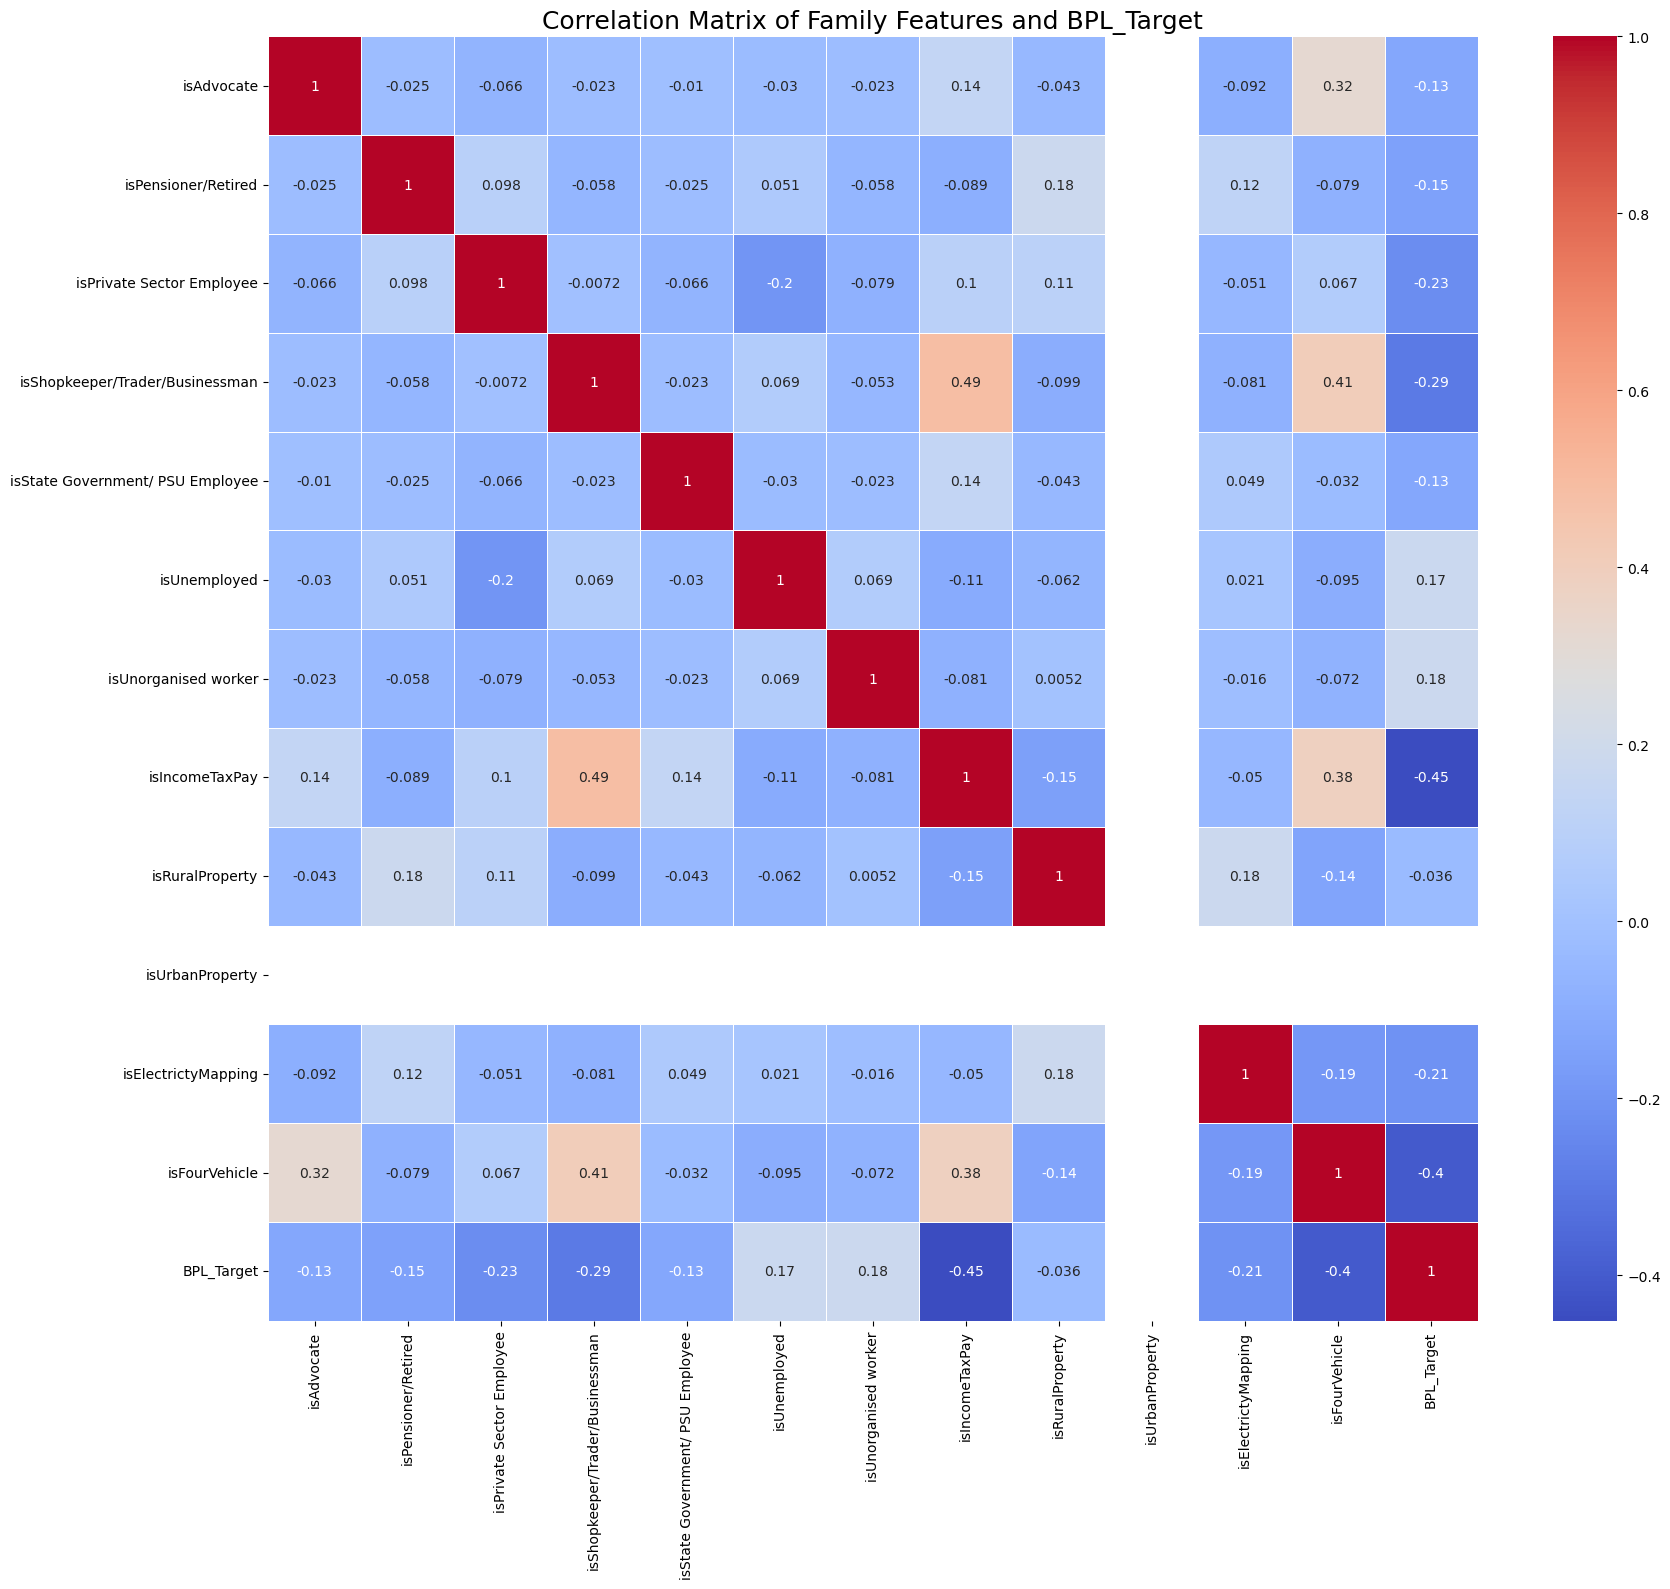

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# CORRELATION MATRIX GENERATION
print("\n--- Generating Correlation Matrix ---")

# Wanting the model to learn based on jobs, vehicles, and assets, not direct income counts.
income_cols = [col for col in df.columns if col.startswith('in') and any(char.isdigit() for char in col)]

cols_to_exclude = ['hasfamilyid', 'familyRange', 'district', 'RuralUrban', 'isChild', 'isHousewife', 'isSenior Citizen', 'isStudent'] + income_cols 
# Comment '+ income_cols' and the lines of code above the comment in the 100-Families.ipynb to add the Per Member Salary to the training dataset
num_df = df.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Ensuring remaining columns are strictly numerical
num_df = num_df.select_dtypes(include=['int64', 'float64'])

# Computing the correlation matrix
corr_matrix = num_df.corr()

# Creating the Heatmap Plot
fig, ax = plt.subplots(figsize=(18, 16))

# Optional: Create a mask to hide the upper triangle for better readability
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
   # mask=mask, 
    annot=True,            # Set to False if we do not want numbers inside the boxes
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=ax
)

plt.title('Correlation Matrix of Family Features and BPL_Target', fontsize=18)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Saving and exporting the plot
matrix_file = 'correlation_matrix.png'
plt.savefig(matrix_file, dpi=300)
print(f"Correlation heatmap saved to '{matrix_file}'.")

# Printing the highest correlating features with BPL_Target
print("\nTop Correlations with BPL_Target:")
target_corr = corr_matrix['BPL_Target'].sort_values(ascending=False)
print(target_corr)